In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [178]:
df=pd.read_csv('../train_prepared.csv')
df.head()

,region,parent_category_name,category_name,param_1,param_2,param_3,price,item_seq_number,user_type,image,deal_probability,has_params,description_len,description_group
0,Свердловская область,Личные вещи,Товары для детей и игрушки,1,0,0,400.00,2,Private,1,0.13,1,58,3. Оптимальное
1,Самарская область,Для дома и дачи,Мебель и интерьер,1,0,0,3000.00,19,Private,1,0.00,1,41,2. Очень короткое
2,Ростовская область,Бытовая электроника,Аудио и видео,1,0,0,4000.00,9,Private,1,0.43,1,99,3. Оптимальное
3,Татарстан,Личные вещи,Товары для детей и игрушки,1,0,0,2200.00,286,Company,1,0.80,1,22,2. Очень короткое
4,Волгоградская область,Транспорт,Автомобили,1,1,1,40000.00,3,Private,1,0.21,1,24,2. Очень короткое


In [179]:
df.groupby('category_name')['category_name'].count().describe()

count     47.00
mean    1046.11
std     1852.39
min        2.00
25%      229.00
50%      362.00
75%      940.50
max     9232.00
Name: category_name, dtype: float64

/var/folders/64/k_35rwnn74355sshxx368brh0000gn/T/ipykernel_92207/2445733651.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(


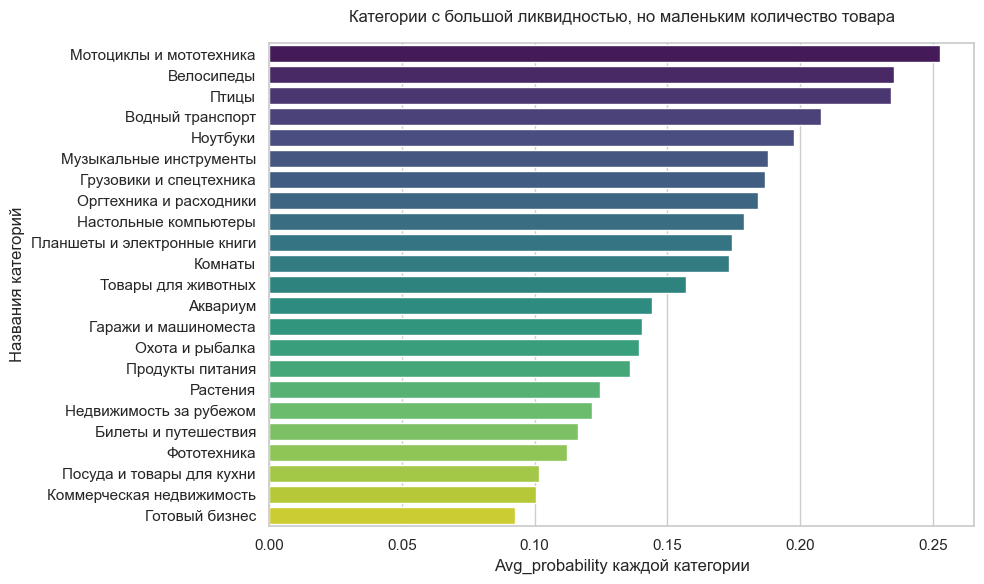

In [180]:
liq_low_ad=df.groupby('category_name')[['category_name','deal_probability']].agg(
    num_of_ad=('category_name', 'count'),
    avg_probability=('deal_probability', 'mean')
).reset_index()
liq_low_ad=liq_low_ad.query("num_of_ad<362")
liq_low_ad=liq_low_ad.sort_values(by='avg_probability', ascending=False)
liq_low_ad

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax=sns.barplot(
    x='avg_probability',
    y='category_name',
    data=liq_low_ad,
    palette='viridis'
)

plt.title('Категории с большой ликвидностью, но маленьким количество товара', fontsize=12, pad=15)
plt.xlabel('Avg_probability каждой категории', fontsize=12)
plt.ylabel('Названия категорий', fontsize=12)

plt.tight_layout()
plt.show()

Difference for    param_1  deal_probability
0        0              0.15
1        1              0.14:param_1            1.00
deal_probability   0.02
dtype: float64


/var/folders/64/k_35rwnn74355sshxx368brh0000gn/T/ipykernel_92207/143911946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


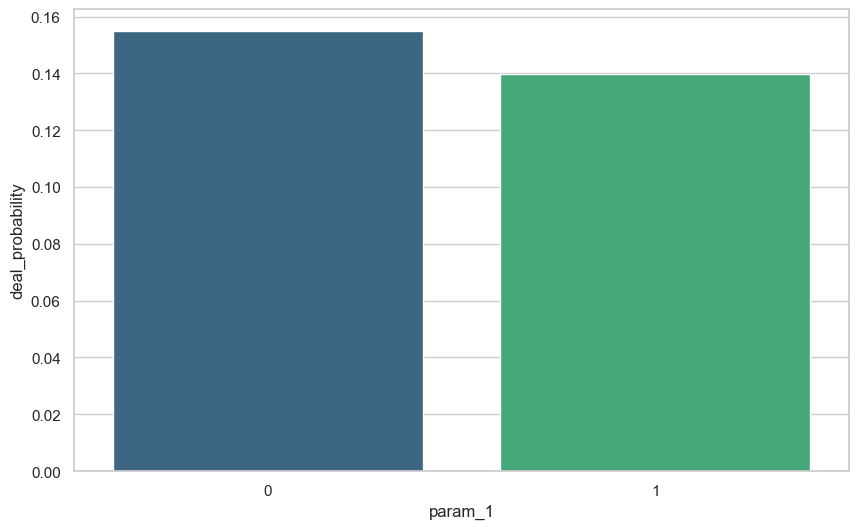

Difference for    param_2  deal_probability
0        0              0.17
1        1              0.12:param_2            1.00
deal_probability   0.05
dtype: float64


/var/folders/64/k_35rwnn74355sshxx368brh0000gn/T/ipykernel_92207/143911946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


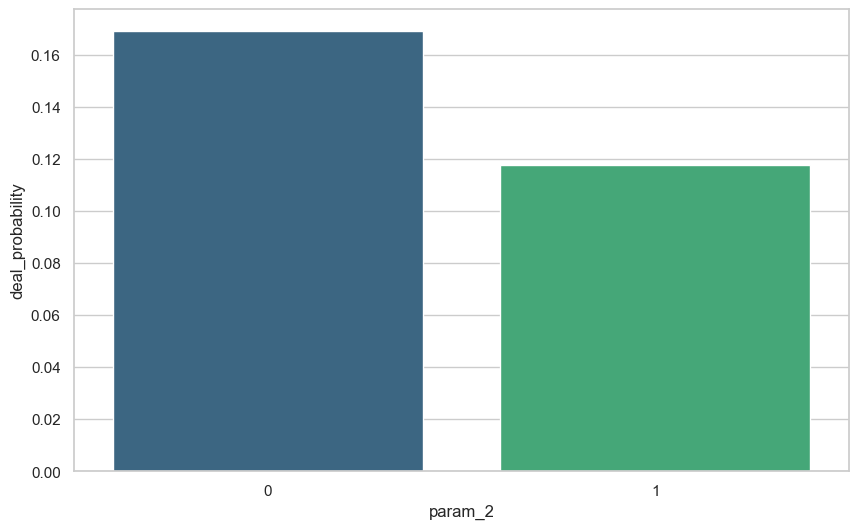

Difference for    param_3  deal_probability
0        0              0.17
1        1              0.09:param_3            1.00
deal_probability   0.08
dtype: float64


/var/folders/64/k_35rwnn74355sshxx368brh0000gn/T/ipykernel_92207/143911946.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


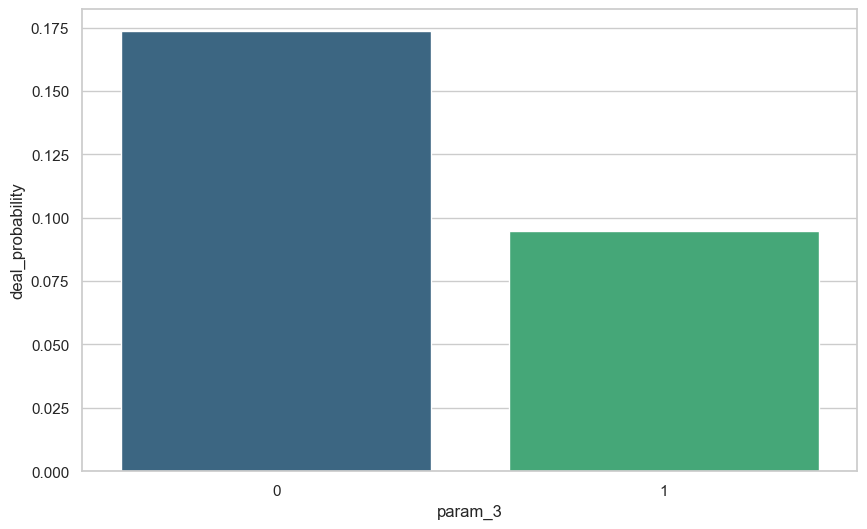

In [181]:
for param in ['param_1', 'param_2', 'param_3']:
    grouped=df.groupby(param)['deal_probability'].mean().reset_index()

    diff=grouped.max()-grouped.min()

    print(f"Difference for {grouped}:{diff}")

    plt.figure(figsize=(10,6))
    sns.barplot(
        x=param,
        y='deal_probability',
        data=grouped,
        palette='viridis'
    )
    plt.show()

In [182]:
matrix_cat_des=df.groupby(['category_name','description_group'])['deal_probability'].mean().unstack()

best_group=matrix_cat_des.idxmax(axis=1)
max_val=matrix_cat_des.max(axis=1)

drop=max_val-matrix_cat_des['5. Слишком длинное']

report = pd.DataFrame({
    'Золотая середина': best_group,
    'Макс. ликвидность': max_val,
    'Падение на длинных текстах': drop
}).reset_index()

report

,category_name,Золотая середина,Макс. ликвидность,Падение на длинных текстах
0,Автомобили,4. Подробное,0.31,0.20
1,Аквариум,3. Оптимальное,0.17,0.07
2,Аудио и видео,2. Очень короткое,0.20,0.08
3,Билеты и путешествия,3. Оптимальное,0.25,0.20
4,Бытовая техника,3. Оптимальное,0.30,0.26
5,Велосипеды,1. Пусто,0.62,0.58
6,Водный транспорт,2. Очень короткое,0.23,0.23
7,Гаражи и машиноместа,1. Пусто,0.25,NaN
8,Готовый бизнес,2. Очень короткое,0.49,0.46
9,Грузовики и спецтехника,2. Очень короткое,0.20,0.14


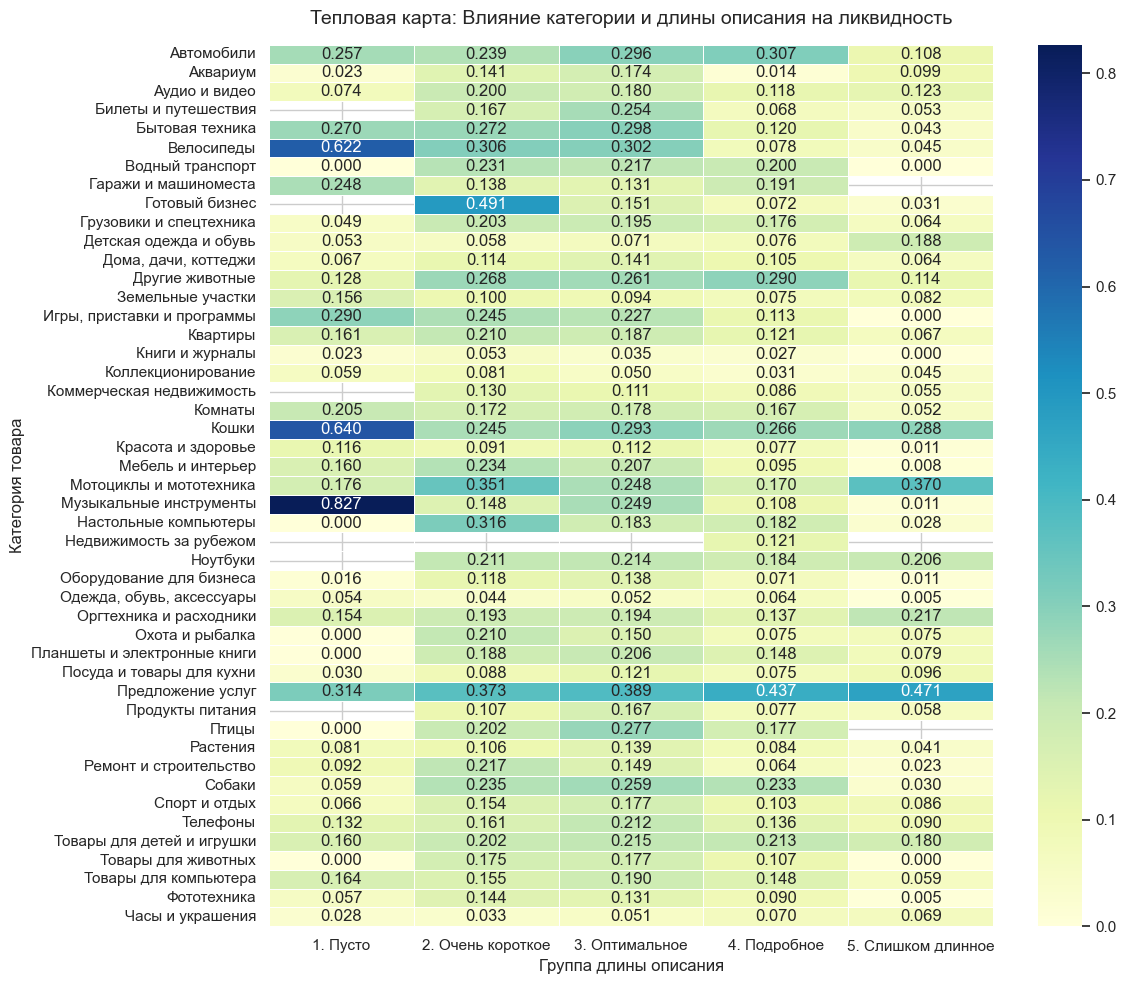

In [183]:
matrix_data = df.pivot_table(
    index='category_name', 
    columns='description_group', 
    values='deal_probability'
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    matrix_data, 
    annot=True,          
    fmt=".3f",           
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar=True            
)

plt.title('Тепловая карта: Влияние категории и длины описания на ликвидность', fontsize=14, pad=15)
plt.xlabel('Группа длины описания', fontsize=12)
plt.ylabel('Категория товара', fontsize=12)

plt.tight_layout()
plt.show()

In [184]:
df['median_price']=df.groupby('category_name')['price'].transform('median')
df['price_ratio']=df['price']/df['median_price']

bins = [0, 0.5, 0.8, 1.1, 1.5, 2, np.inf]
labels = [
    '1. Намного дешевле рынка (меньше половины цены)',
    '2. Скидка (на 20-50% дешевле медианы)',
    '3. Рыночная цена (около медианы +/- 10%)',
    '4. Чуть дороже рынка (на 10-50% дороже)',
    '5. Намного дороже рынка (в 1.5 - 2 раза дороже)',
    '6. Оверпрайс (более чем в 2 раза дороже)'
]

df['price_segment']=pd.cut(df['price_ratio'], bins=bins, labels=labels)
price_impact=df.groupby(['category_name', 'price_segment'])['deal_probability'].mean().unstack()

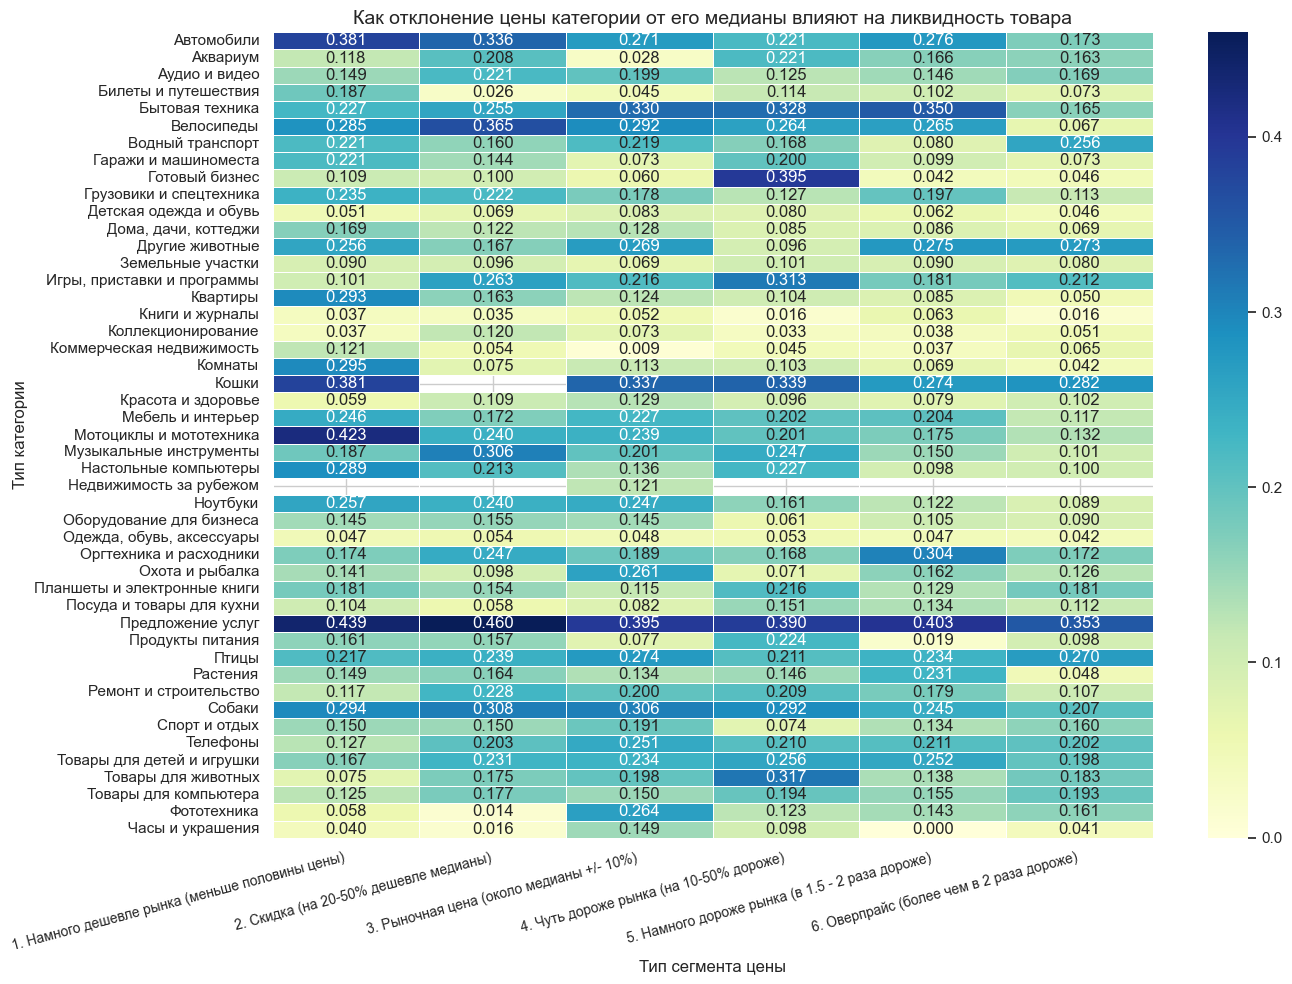

In [185]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    price_impact,
    annot=True,          
    fmt=".3f",           
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar=True 
)

plt.title("Как отклонение цены категории от его медианы влияют на ликвидность товара", fontsize=14)
plt.xlabel("Тип сегмента цены", fontsize=12)
plt.ylabel("Тип категории", fontsize=12)
plt.xticks(rotation=15, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

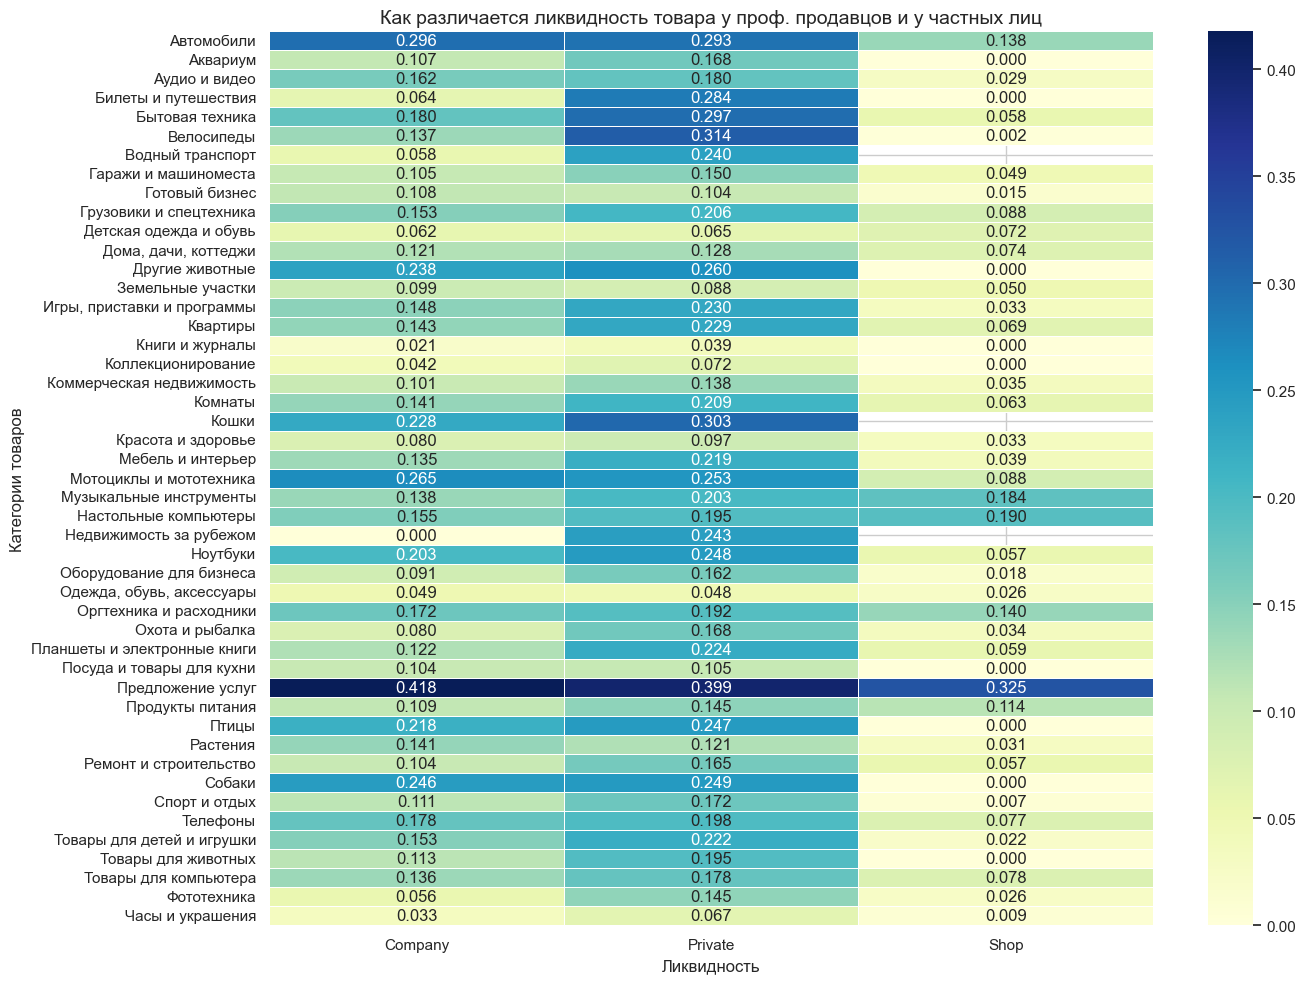

In [186]:
liq_us_type=df.groupby(['user_type', 'category_name'])['deal_probability'].mean().reset_index()

pivot_data=liq_us_type.pivot_table(
    index="category_name",
    columns="user_type",
    values="deal_probability"
)

plt.figure(figsize=(14,10))
sns.heatmap(
    pivot_data,
    annot=True,          
    fmt=".3f",           
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar=True 
)
plt.title("Как различается ликвидность товара у проф. продавцов и у частных лиц", fontsize=14)
plt.xlabel("Ликвидность", fontsize=12)
plt.ylabel("Категории товаров", fontsize=12)
plt.tight_layout()
plt.show()


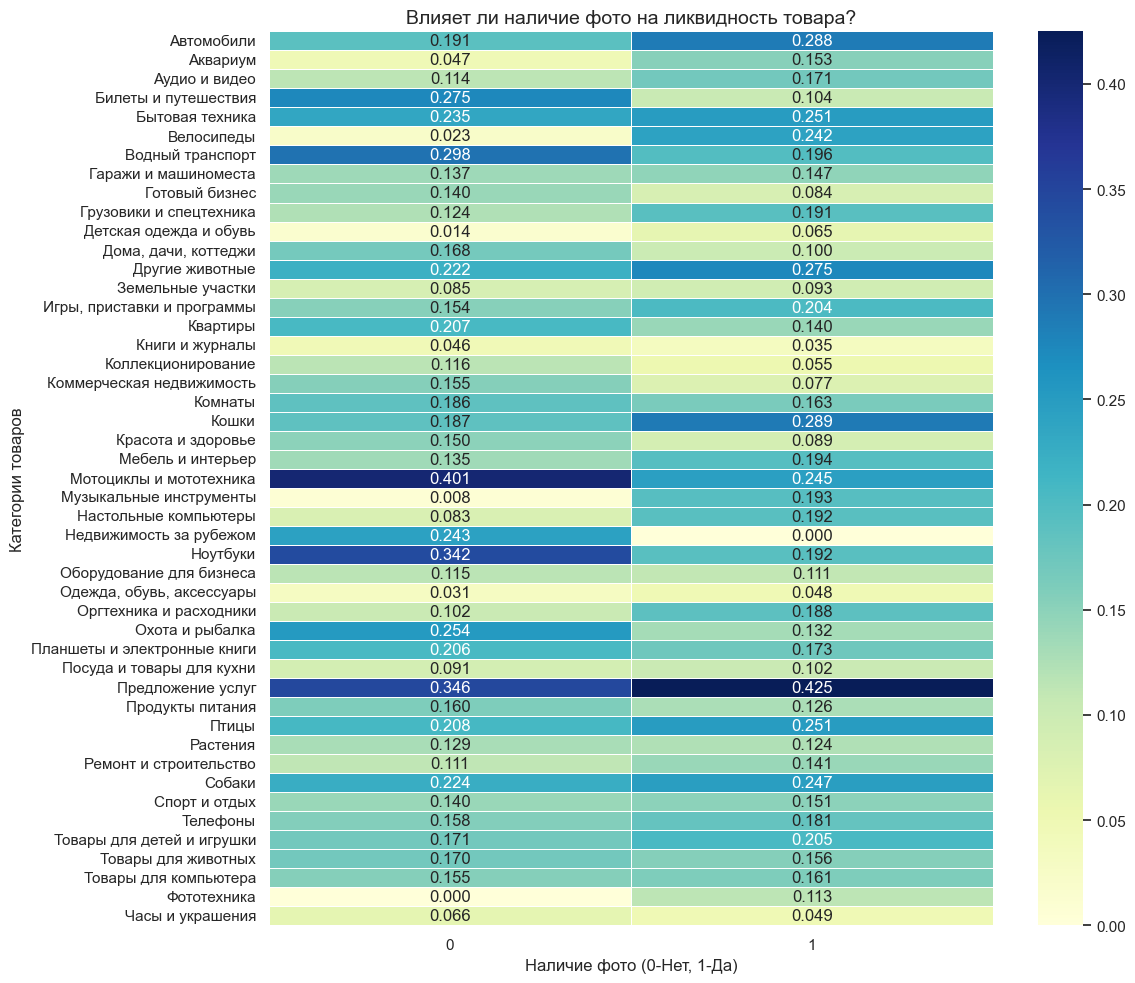

In [187]:
liq_img=df.groupby(['image', 'category_name'])['deal_probability'].mean().reset_index()

pivot_lim_img=liq_img.pivot_table(
    index="category_name",
    columns="image",
    values="deal_probability"
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    pivot_lim_img,
    annot=True,          
    fmt=".3f",           
    cmap="YlGnBu",       
    linewidths=0.5,      
    cbar=True 
)

plt.title("Влияет ли наличие фото на ликвидность товара?", fontsize=14)
plt.xlabel("Наличие фото (0-Нет, 1-Да)", fontsize=12)
plt.ylabel("Категории товаров", fontsize=12)

plt.tight_layout()
plt.show()

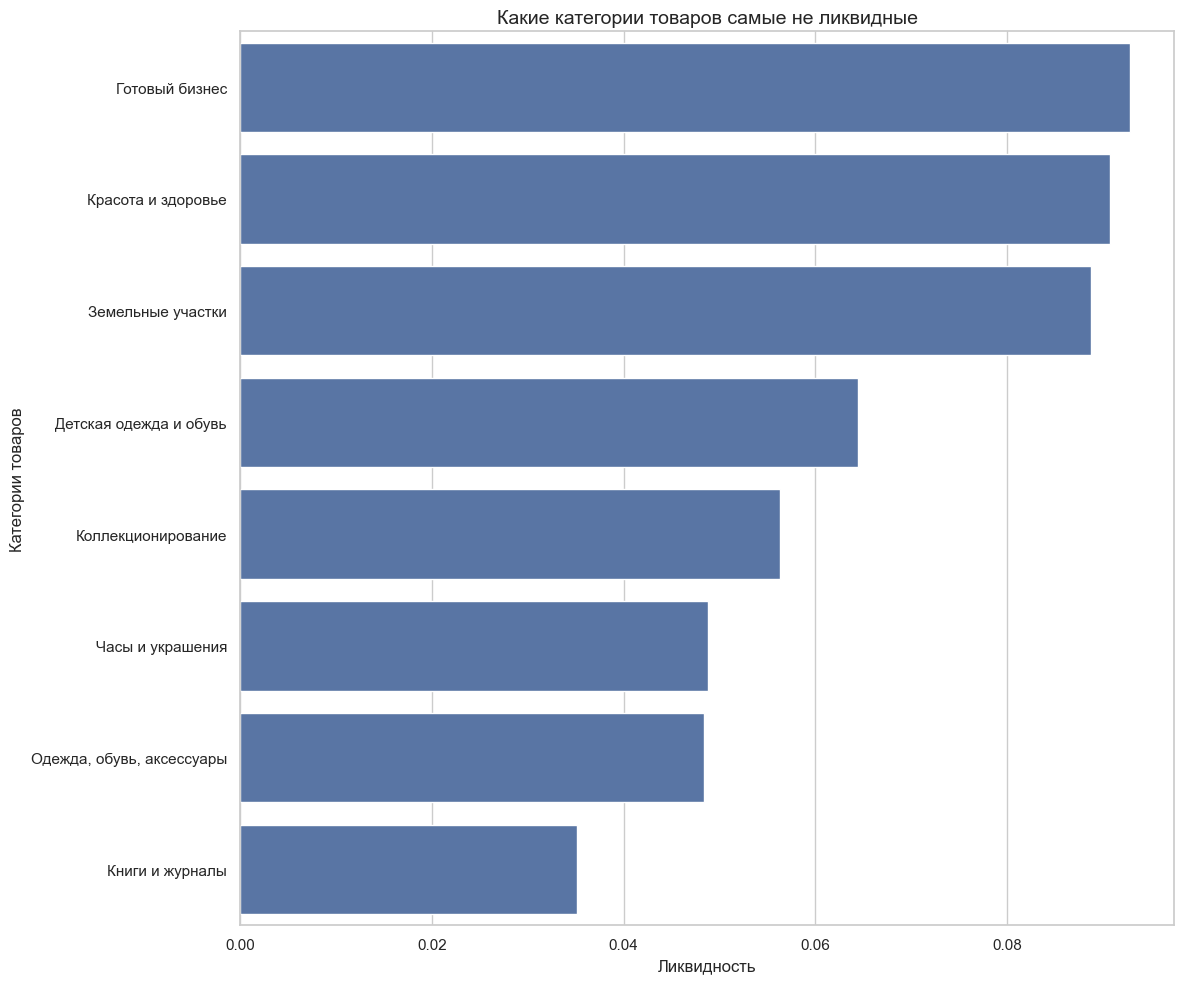

In [188]:
low_liq_cat=df.groupby('category_name')['deal_probability'].mean().reset_index()
low_liq_cat=low_liq_cat.query("deal_probability<0.1")
low_liq_cat=low_liq_cat.sort_values(by="deal_probability", ascending=False)

plt.figure(figsize=(12, 10))

sns.barplot(
    x="deal_probability",
    y="category_name",
    data=low_liq_cat
)

plt.title("Какие категории товаров самые не ликвидные", fontsize=14)
plt.xlabel("Ликвидность", fontsize=12)
plt.ylabel("Категории товаров", fontsize=12)

plt.tight_layout()
plt.show()